In [ ]:
import torch
import torchvision
from torchvision import transforms
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.transforms import functional as F
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load the model of Masked RCNN
model = maskrcnn_resnet50_fpn(pretrained=True)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:01<00:00, 109MB/s]


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [ ]:
# function to load the image
def load_image(image_path):
    img = Image.open(image_path)
    transform = transforms.Compose([
        transforms.ToTensor()
    ])
    return transform(img).unsqueeze(0)  # Add batch dimensions

In [ ]:
# Define the function for prediction
def predict(image):
  image_tensor = load_image(image)
  with torch.no_grad():
    prediction = model(image_tensor)

  return prediction

In [ ]:
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter',
    'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra',
    'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard',
    'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon',
    'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet',
    'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster',
    'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]

In [ ]:
predictions = predict('jungle.jpg')

In [ ]:
predictions

[{'boxes': tensor([[416.1658, 213.5272, 618.6298, 294.9222],
          [ 47.0028, 234.2588, 162.7326, 395.3300],
          [ 89.9395, 231.5175, 211.4969, 347.4781],
          [254.5588, 236.8033, 341.3957, 270.9430]]),
  'labels': tensor([25, 24, 24, 24]),
  'scores': tensor([0.9989, 0.9989, 0.9979, 0.9962]),
  'masks': tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            ...,
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.]]],
  
  
          [[[0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            ...,
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.]]],
  
  
          [[[0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0

In [ ]:
masks = predictions[0]['masks']

In [ ]:
len(masks)

4

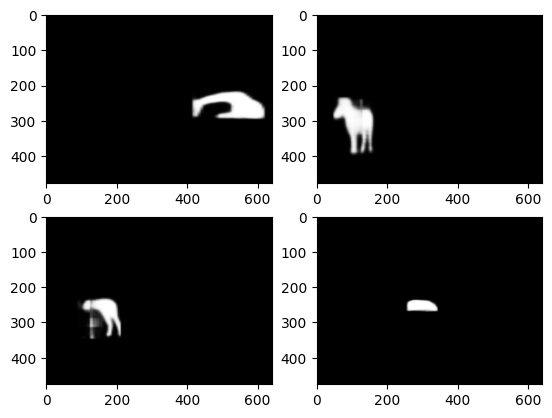

In [ ]:
for i in range(len(masks)):
  plt.subplot(2,2,i+1)
  plt.imshow(masks[i].reshape(476, 640), cmap='gray')

In [ ]:
def visualize_predictions(image, predictions):
  image = plt.imread(image)
  plt.figure(figsize=(10, 10))
  plt.imshow(image)

  boxes = predictions[0]['boxes'].cpu().numpy()
  labels = predictions[0]['labels'].cpu().numpy()
  scores = predictions[0]['scores'].cpu().numpy()
  masks = predictions[0]['masks'].cpu().numpy()  # Extract the masks

  keep = scores > 0.5
  boxes = boxes[keep]
  labels = labels[keep]
  scores = scores[keep]
  masks = masks[keep]   # Keep the masks

  for box, mask, label, score in zip(boxes, masks, labels, scores):
    box = box.astype(int)
    x1, y1, x2, y2 = box
    plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                      fill=False, color='r', linewidth=2))
    label_text = f"{COCO_INSTANCE_CATEGORY_NAMES[label - 1]}: {score:.2f}"
    plt.text(x1, y1-5, label_text, color='y', fontsize=10, weight='bold')
    mask = mask > 0.5
    mask = mask.reshape(image.shape[0], image.shape[1])
    plt.imshow(mask, alpha=0.25)

  plt.show()

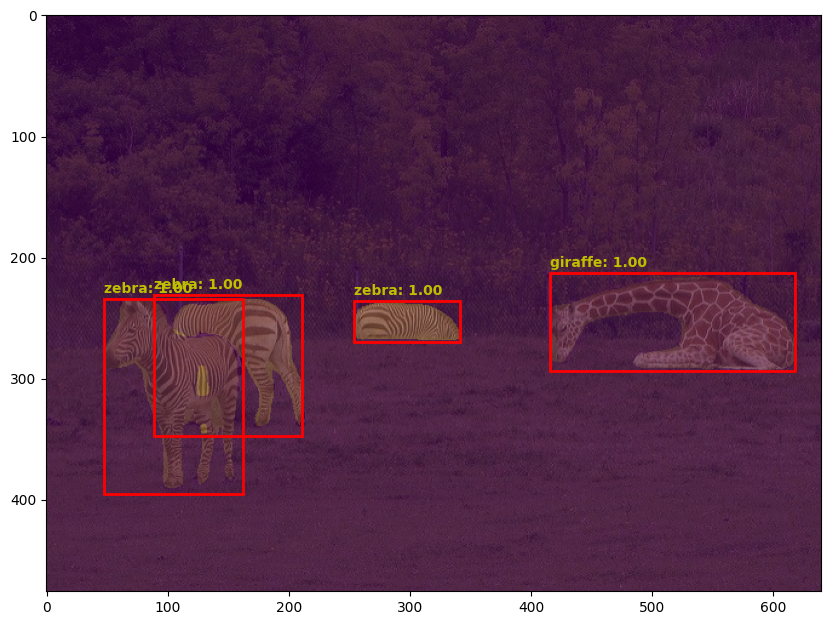

In [ ]:
predictions = predict('jungle.jpg')
visualize_predictions('jungle.jpg', predictions)

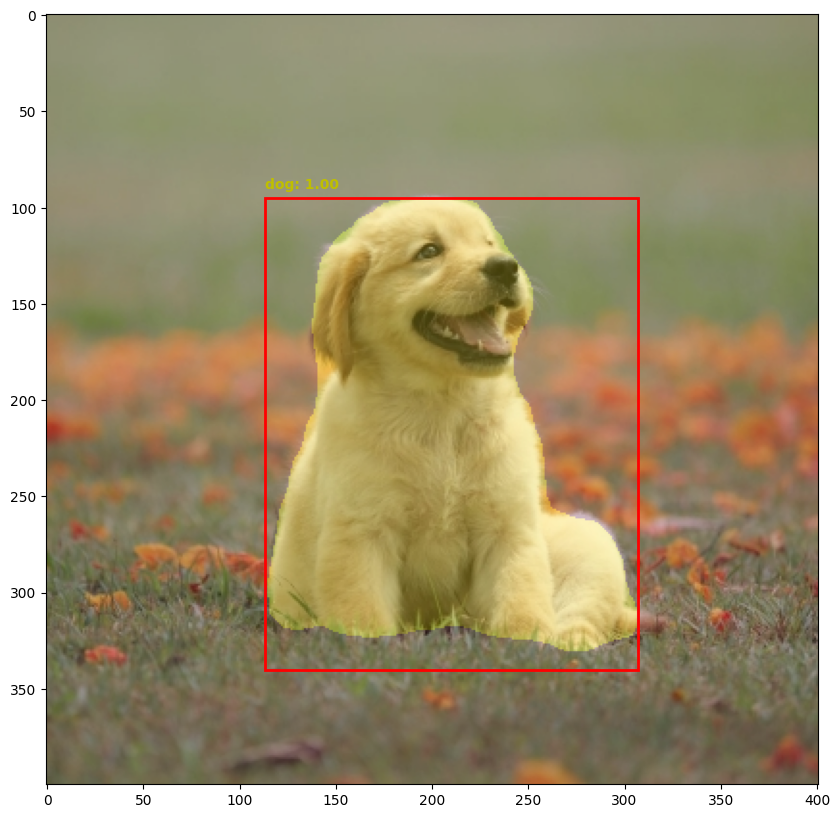

In [ ]:
predictions = predict('dog.jpg')
visualize_predictions('dog.jpg', predictions)